Saving animation to random_galton_run_630.gif...
Done!


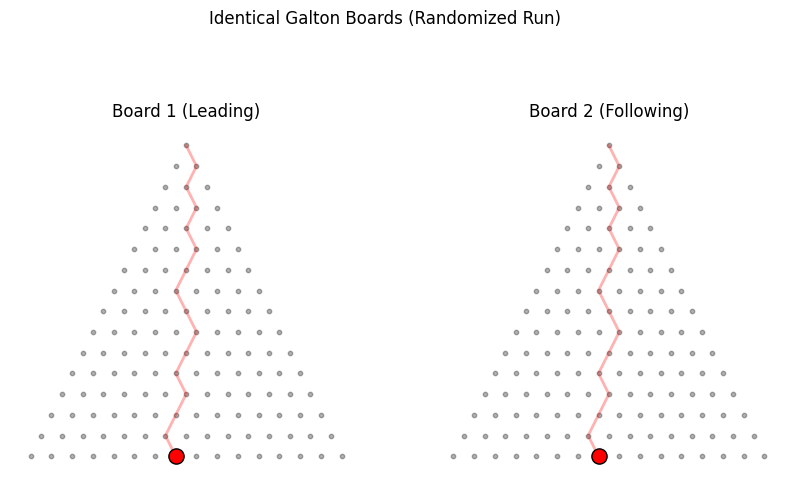

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import random

# --- Parameters ---
n_steps = 15
frames_per_step = 30  # Controls the speed of the fall
delay_frames = 10     # How many frames Board 2 is behind Board 1
total_frames = (n_steps * frames_per_step) + delay_frames + 50 

# --- Generate the Random Path (Unique per run) ---
# We removed np.random.seed(), so this is different every time you run the script.
decisions = np.random.choice([-0.5, 0.5], size=n_steps)

# Calculate coordinates based on the random decisions
# This path is calculated once, so both boards will still match each other.
path_x = np.zeros(n_steps + 1)
path_x[1:] = np.cumsum(decisions)
path_y = np.arange(0, -(n_steps + 1), -1)

# --- Setup the Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
fig.suptitle('Identical Galton Boards (Randomized Run)')

def setup_board(ax, title):
    """Draws the static pegs and sets up the axis."""
    ax.set_title(title)
    ax.set_xlim(-(n_steps/2 + 1), (n_steps/2 + 1))
    ax.set_ylim(-(n_steps + 1), 1)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Draw Pegs
    for r in range(n_steps + 1):
        pegs_x = np.linspace(-r/2, r/2, r+1)
        pegs_y = np.full_like(pegs_x, -r)
        ax.scatter(pegs_x, pegs_y, c='black', s=10, alpha=0.3)

setup_board(ax1, "Board 1 (Leading)")
setup_board(ax2, "Board 2 (Following)")

# --- Initialize Ball Objects ---
ball1 = ax1.scatter([], [], c='red', s=120, zorder=10, edgecolors='black')
ball2 = ax2.scatter([], [], c='red', s=120, zorder=10, edgecolors='black')

# Trace lines
trace1, = ax1.plot([], [], 'r-', alpha=0.3, lw=2)
trace2, = ax2.plot([], [], 'r-', alpha=0.3, lw=2)

# --- Helper Function for Position ---
def get_position(frame):
    """Calculates the (x, y) position of the ball at a given frame."""
    if frame < 0:
        return None, None 
        
    step_float = frame / frames_per_step
    step_idx = int(step_float)
    
    if step_idx >= n_steps:
        return path_x[-1], path_y[-1]
        
    alpha = step_float % 1
    
    curr_x, next_x = path_x[step_idx], path_x[step_idx+1]
    curr_y, next_y = path_y[step_idx], path_y[step_idx+1]
    
    pos_x = curr_x + (next_x - curr_x) * alpha
    pos_y = curr_y + (next_y - curr_y) * alpha
    
    return pos_x, pos_y

# --- Animation Function ---
def animate(i):
    # Board 1
    x1, y1 = get_position(i)
    if x1 is not None:
        ball1.set_offsets([[x1, y1]])
        current_step = min(int(i / frames_per_step), n_steps)
        trace1.set_data(path_x[:current_step+1], path_y[:current_step+1])
    
    # Board 2 (Delayed)
    x2, y2 = get_position(i - delay_frames)
    if x2 is not None:
        ball2.set_offsets([[x2, y2]])
        current_step_2 = min(int((i - delay_frames) / frames_per_step), n_steps)
        trace2.set_data(path_x[:current_step_2+1], path_y[:current_step_2+1])
    else:
        ball2.set_offsets(np.empty((0, 2)))
        trace2.set_data([], [])
        
    return ball1, ball2, trace1, trace2

# --- Create and Save ---
ani = animation.FuncAnimation(fig, animate, frames=total_frames, 
                              interval=20, blit=True, repeat=False)

# Save to GIF using Pillow (standard library compatible)
filename = f"random_galton_run_{random.randint(0, 1000)}.gif"
print(f"Saving animation to {filename}...")
ani.save(filename, writer='pillow', fps=30)
print("Done!")